# DE_IP_2024 — домашнее задание №2

Размер изображения: 1200 x 675


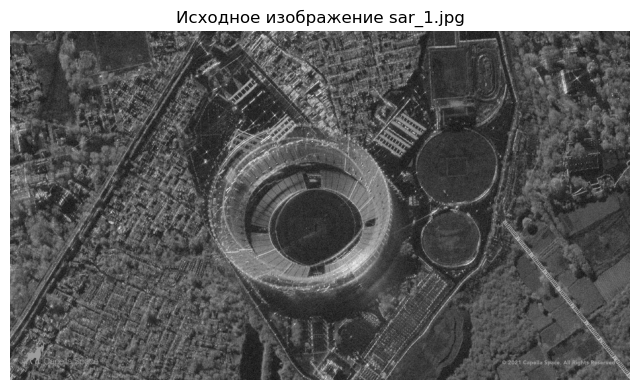

In [10]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['image.cmap'] = 'gray'

IMAGE_PATH = Path('sar_1.jpg')
IMAGE_URL = (
    'https://sc04.alicdn.com/kf/'
    'Aa9b902d1d96a42428a9fd49e593430272.jpg'
)

if not IMAGE_PATH.exists():
    print('Файл sar_1.jpg не найден. Загружаю приложенное изображение...')
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f'Не удалось прочитать изображение: {IMAGE_PATH.resolve()}')

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
height, width = image_gray.shape
print(f'Размер изображения: {width} x {height}')

plt.figure(figsize=(8, 6))
plt.imshow(image_gray)
plt.title('Исходное изображение sar_1.jpg')
plt.axis('off');

## 1. Формирование тестовых шумов

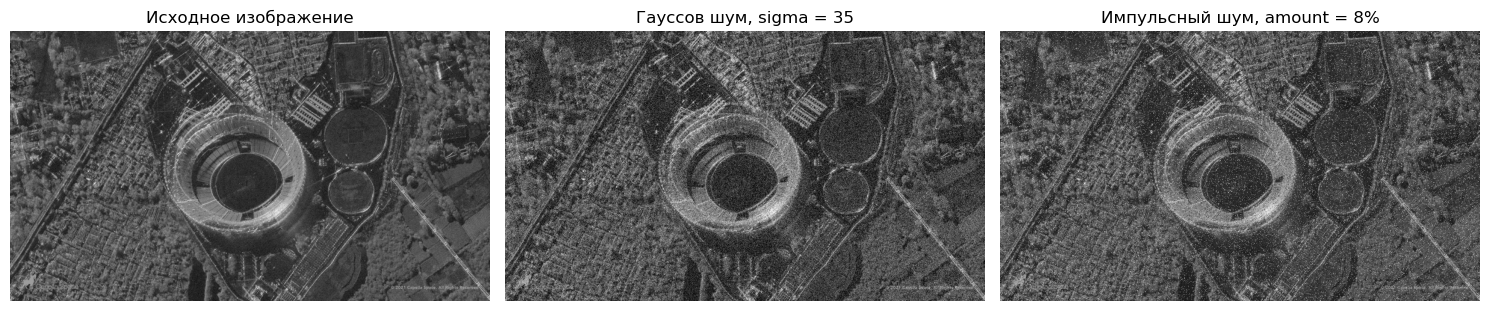

In [11]:
rng = np.random.default_rng(42)

def add_gaussian_noise(image, sigma=35, generator=None):
    if generator is None:
        generator = np.random.default_rng(42)
    noise = generator.normal(0, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.08, salt_ratio=0.5, generator=None):
    if generator is None:
        generator = np.random.default_rng(42)
    noisy = image.copy()
    count = int(amount * image.size)
    rows = generator.integers(0, image.shape[0], count)
    cols = generator.integers(0, image.shape[1], count)
    salt_count = int(count * salt_ratio)
    noisy[rows[:salt_count], cols[:salt_count]] = 255
    noisy[rows[salt_count:], cols[salt_count:]] = 0
    return noisy

image_gaussian = add_gaussian_noise(image_gray, sigma=35, generator=rng)
image_salt_pepper = add_salt_pepper_noise(image_gray, amount=0.08, generator=rng)

plt.figure(figsize=(15, 5))
for index, (title, image) in enumerate([
    ('Исходное изображение', image_gray),
    ('Гауссов шум, sigma = 35', image_gaussian),
    ('Импульсный шум, amount = 8%', image_salt_pepper),
], start=1):
    plt.subplot(1, 3, index)
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
plt.tight_layout();

## 2. Метрики качества

In [12]:
def mse(reference, image):
    reference = reference.astype(np.float32)
    image = image.astype(np.float32)
    return float(np.mean((reference - image) ** 2))

def psnr(reference, image):
    error = mse(reference, image)
    if error == 0:
        return float('inf')
    return float(10 * np.log10((255.0 ** 2) / error))

def ssim_score(reference, image):
    reference = reference.astype(np.float32)
    image = image.astype(np.float32)
    kernel_size = (11, 11)
    sigma = 1.5
    mu_ref = cv2.GaussianBlur(reference, kernel_size, sigma)
    mu_img = cv2.GaussianBlur(image, kernel_size, sigma)
    mu_ref_sq = mu_ref * mu_ref
    mu_img_sq = mu_img * mu_img
    mu_product = mu_ref * mu_img
    sigma_ref_sq = cv2.GaussianBlur(reference * reference, kernel_size, sigma) - mu_ref_sq
    sigma_img_sq = cv2.GaussianBlur(image * image, kernel_size, sigma) - mu_img_sq
    sigma_product = cv2.GaussianBlur(reference * image, kernel_size, sigma) - mu_product
    c1 = (0.01 * 255) ** 2
    c2 = (0.03 * 255) ** 2
    numerator = (2 * mu_product + c1) * (2 * sigma_product + c2)
    denominator = (mu_ref_sq + mu_img_sq + c1) * (sigma_ref_sq + sigma_img_sq + c2)
    return float(np.mean(numerator / (denominator + 1e-12)))

def metrics(reference, image):
    return {
        'MSE': mse(reference, image),
        'PSNR': psnr(reference, image),
        'SSIM': ssim_score(reference, image),
    }

print('Гауссов шум:', metrics(image_gray, image_gaussian))
print('Импульсный шум:', metrics(image_gray, image_salt_pepper))

Гауссов шум: {'MSE': 1144.7879638671875, 'PSNR': 17.543553062006968, 'SSIM': 0.3164272904396057}
Импульсный шум: {'MSE': 1489.70947265625, 'PSNR': 16.39978781532736, 'SSIM': 0.3587328791618347}


## 3. Набор фильтров и параметров

In [13]:
filter_specs = [
    ('Медианный 3x3', lambda image: cv2.medianBlur(image, 3)),
    ('Медианный 5x5', lambda image: cv2.medianBlur(image, 5)),
    ('Медианный 7x7', lambda image: cv2.medianBlur(image, 7)),
    ('Гауссов 3x3, sigma=0', lambda image: cv2.GaussianBlur(image, (3, 3), 0)),
    ('Гауссов 5x5, sigma=1', lambda image: cv2.GaussianBlur(image, (5, 5), 1)),
    ('Гауссов 7x7, sigma=2', lambda image: cv2.GaussianBlur(image, (7, 7), 2)),
    ('Билатеральный d=5', lambda image: cv2.bilateralFilter(image, 5, 25, 25)),
    ('Билатеральный d=9', lambda image: cv2.bilateralFilter(image, 9, 50, 50)),
    ('Билатеральный d=13', lambda image: cv2.bilateralFilter(image, 13, 75, 75)),
    ('NLM h=5', lambda image: cv2.fastNlMeansDenoising(image, None, 5, 7, 21)),
    ('NLM h=10', lambda image: cv2.fastNlMeansDenoising(image, None, 10, 7, 21)),
    ('NLM h=20', lambda image: cv2.fastNlMeansDenoising(image, None, 20, 7, 21)),
]
print(f'Количество вариантов фильтрации: {len(filter_specs)}')

Количество вариантов фильтрации: 12


In [14]:
def run_experiment(noisy_image, noise_name):
    rows = []
    results = {}
    for filter_name, filter_function in filter_specs:
        filtered = filter_function(noisy_image)
        results[filter_name] = filtered
        row = {'Шум': noise_name, 'Фильтр': filter_name}
        row.update(metrics(image_gray, filtered))
        rows.append(row)
    return rows, results

gaussian_rows, gaussian_results = run_experiment(image_gaussian, 'Гауссов')
sp_rows, sp_results = run_experiment(image_salt_pepper, 'Импульсный')
all_rows = gaussian_rows + sp_rows

def sort_key(row):
    return (-row['SSIM'], -row['PSNR'], row['MSE'])

best_gaussian_ssim = sorted(gaussian_rows, key=sort_key)[0]
best_sp_ssim = sorted(sp_rows, key=sort_key)[0]
print('Лучший результат для гауссова шума по SSIM:', best_gaussian_ssim)
print('Лучший результат для импульсного шума по SSIM:', best_sp_ssim)

Лучший результат для гауссова шума по SSIM: {'Шум': 'Гауссов', 'Фильтр': 'Гауссов 5x5, sigma=1', 'MSE': 199.42050170898438, 'PSNR': 25.133105563336827, 'SSIM': 0.6281977891921997}
Лучший результат для импульсного шума по SSIM: {'Шум': 'Импульсный', 'Фильтр': 'Медианный 3x3', 'MSE': 104.47193145751953, 'PSNR': 27.940807369329633, 'SSIM': 0.7821590900421143}


## 4. Сравнение результатов

In [15]:
def print_table(rows, title):
    print(title)
    print(f"{'Фильтр':<28} {'MSE':>12} {'PSNR':>10} {'SSIM':>10}")
    print('-' * 64)
    for row in sorted(rows, key=sort_key):
        print(f"{row['Фильтр']:<28} {row['MSE']:>12.2f} {row['PSNR']:>10.2f} {row['SSIM']:>10.4f}")

print_table(gaussian_rows, 'Гауссов шум')
print()
print_table(sp_rows, 'Импульсный шум')

Гауссов шум
Фильтр                                MSE       PSNR       SSIM
----------------------------------------------------------------
Гауссов 5x5, sigma=1               199.42      25.13     0.6282
Гауссов 3x3, sigma=0               228.38      24.54     0.6097
Гауссов 7x7, sigma=2               240.90      24.31     0.5359
Билатеральный d=9                  292.04      23.48     0.5250
Билатеральный d=13                 268.26      23.85     0.5200
Медианный 3x3                      312.53      23.18     0.5151
Медианный 5x5                      279.23      23.67     0.4855
Медианный 7x7                      306.32      23.27     0.4343
NLM h=20                           691.09      19.74     0.4114
Билатеральный d=5                  726.39      19.52     0.3896
NLM h=5                           1144.79      17.54     0.3164
NLM h=10                          1144.79      17.54     0.3164

Импульсный шум
Фильтр                                MSE       PSNR       SSIM
-----------

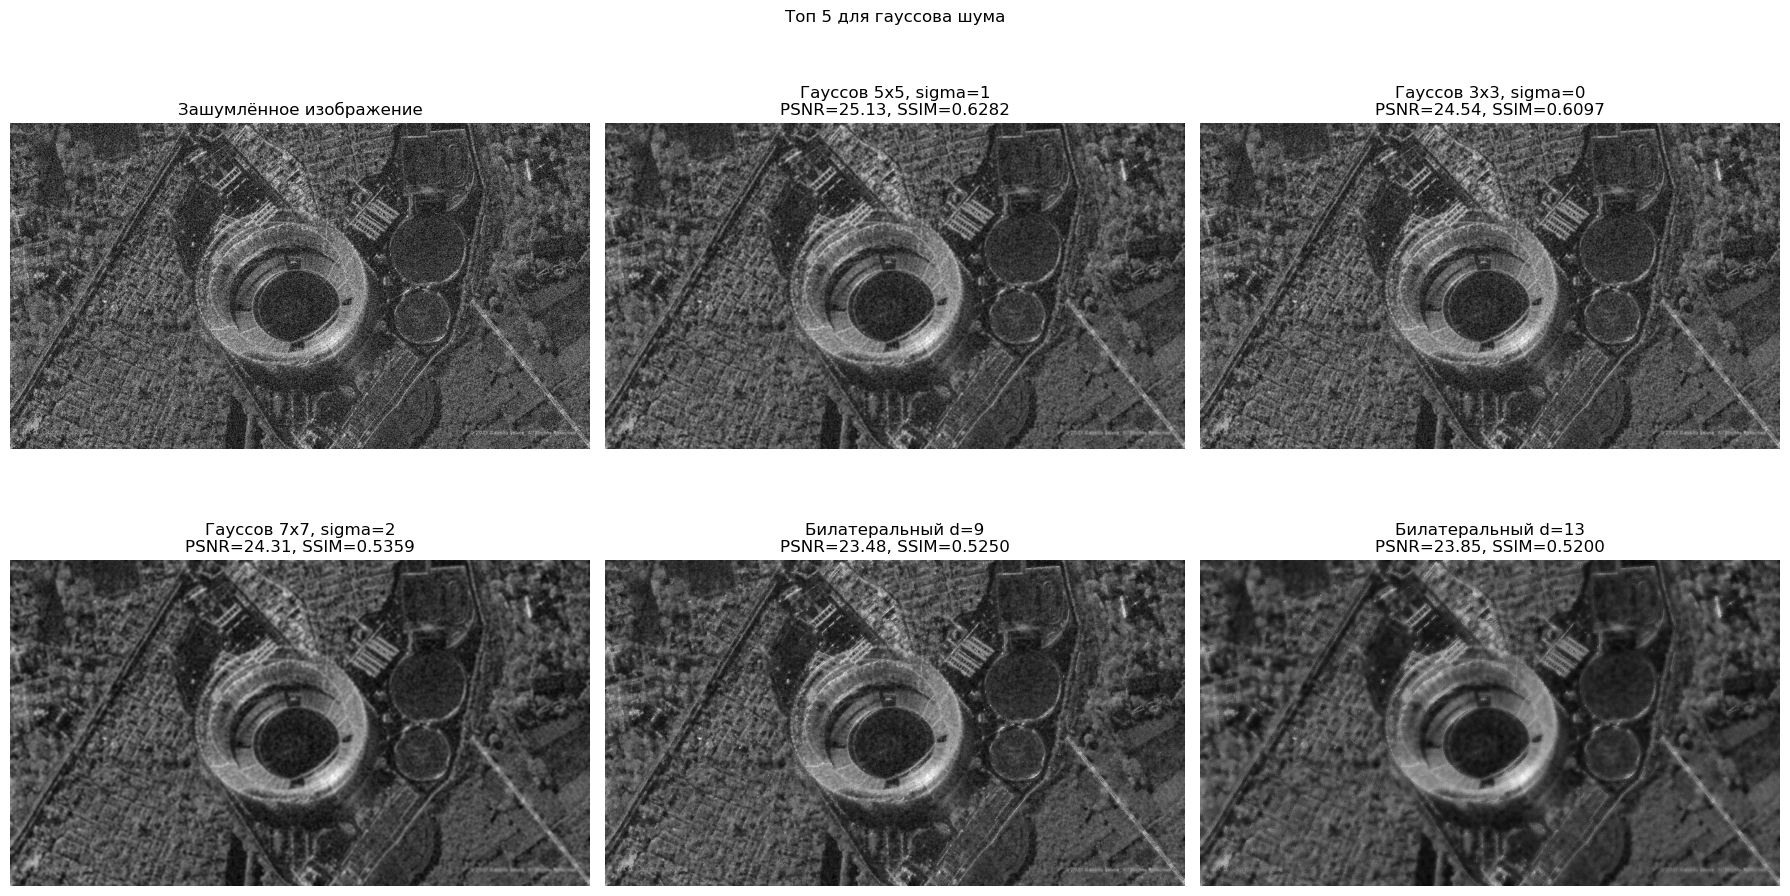

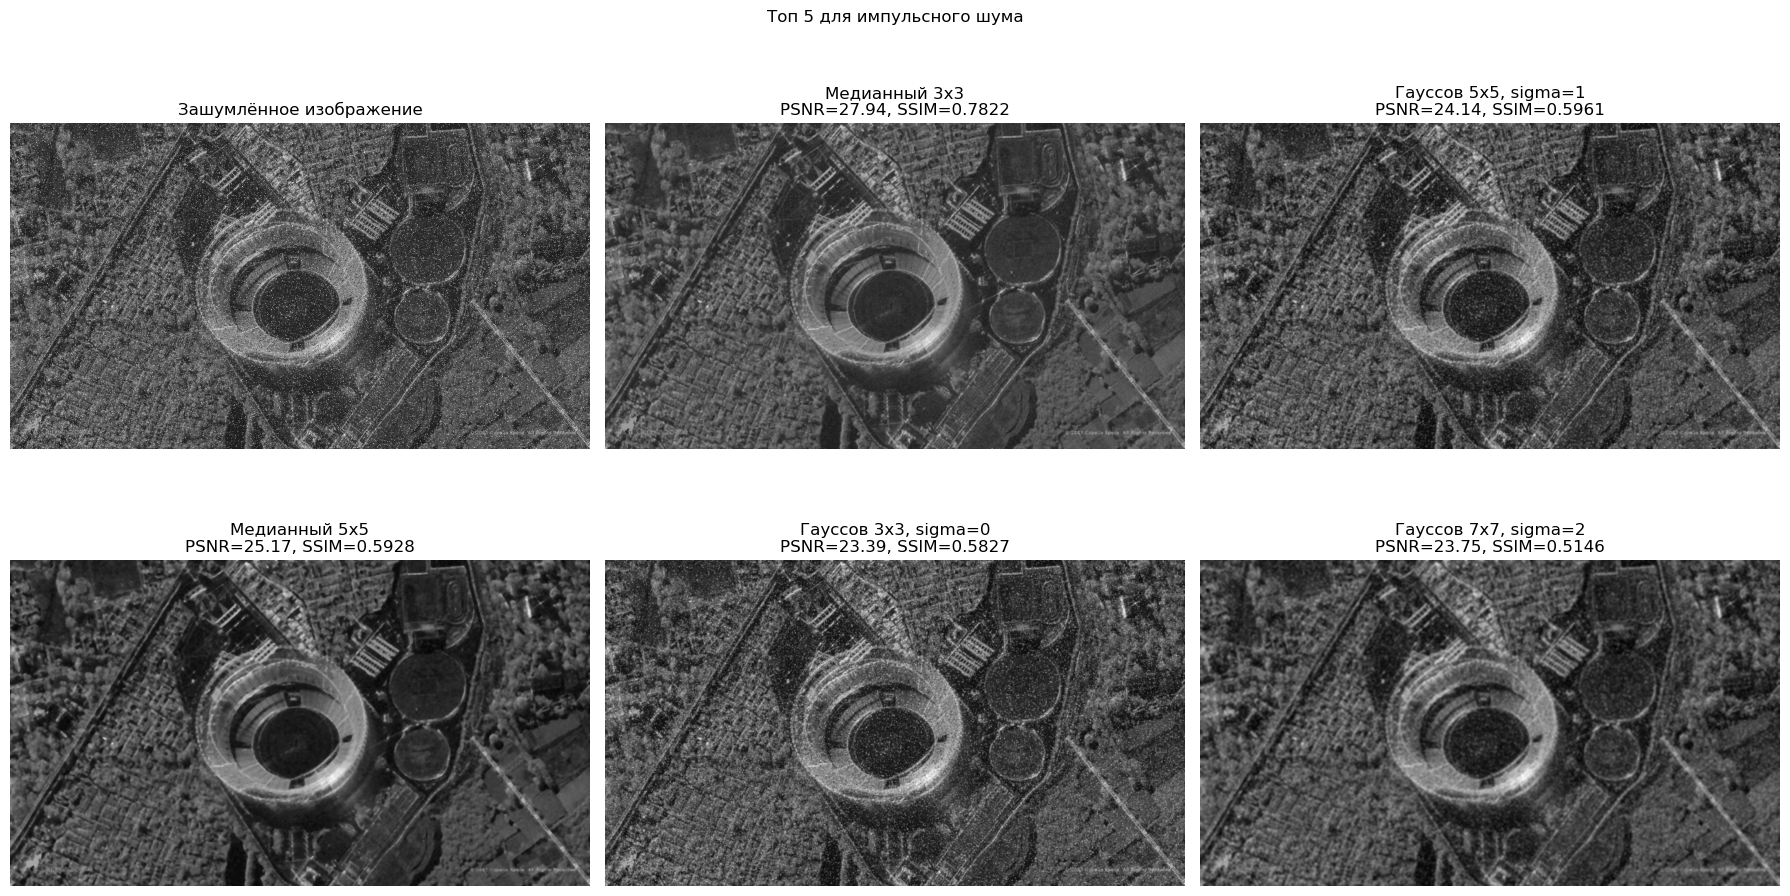

In [16]:
def show_top_results(noisy_image, result_dict, rows, title, count=5):
    selected_rows = sorted(rows, key=sort_key)[:count]
    plt.figure(figsize=(18, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(noisy_image)
    plt.title('Зашумлённое изображение')
    plt.axis('off')
    for index, row in enumerate(selected_rows, start=2):
        plt.subplot(2, 3, index)
        plt.imshow(result_dict[row['Фильтр']])
        plt.title(
            f"{row['Фильтр']}\n"
            f"PSNR={row['PSNR']:.2f}, SSIM={row['SSIM']:.4f}"
        )
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout();

show_top_results(
    image_gaussian, gaussian_results, gaussian_rows,
    'Топ 5 для гауссова шума'
)
show_top_results(
    image_salt_pepper, sp_results, sp_rows,
    'Топ 5 для импульсного шума'
)

## 5. Итоговый вывод

In [17]:
print('Вывод')
print(f"Гауссов шум: лучший фильтр — {best_gaussian_ssim['Фильтр']}")
print(f"  MSE={best_gaussian_ssim['MSE']:.2f}, PSNR={best_gaussian_ssim['PSNR']:.2f}, SSIM={best_gaussian_ssim['SSIM']:.4f}")
print(f"Импульсный шум: лучший фильтр — {best_sp_ssim['Фильтр']}")
print(f"  MSE={best_sp_ssim['MSE']:.2f}, PSNR={best_sp_ssim['PSNR']:.2f}, SSIM={best_sp_ssim['SSIM']:.4f}")

Вывод
Гауссов шум: лучший фильтр — Гауссов 5x5, sigma=1
  MSE=199.42, PSNR=25.13, SSIM=0.6282
Импульсный шум: лучший фильтр — Медианный 3x3
  MSE=104.47, PSNR=27.94, SSIM=0.7822
